# DBSCAN Clustering with Noise 🔬

In this notebook, we implement **DBSCAN** (**D**ensity-**B**ased **S**patial **C**lustering of **A**pplications with **N**oise).

We will use a slightly noisier dataset to demonstrate how DBSCAN effectively identifies and ignores outliers.

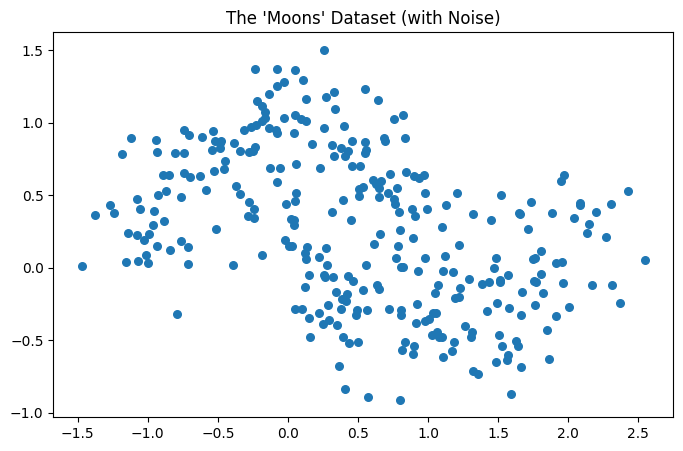

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

np.random.seed(42)

# 1. Generate Data with Noise
# Setting noise=0.2 makes the data messier, creating distinct outliers
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title("The 'Moons' Dataset (with Noise)")
plt.show()

## 1. Finding Neighbors 🔍

We need a function to find all points close to a given point.

In [3]:
def get_neighbors(X, point_idx, eps):
    """Finds indices of all points within distance 'eps' of X[point_idx]"""
    neighbors = []
    for i in range(len(X)):
        # Calculate Euclidean distance
        dist = np.sqrt(np.sum((X[point_idx] - X[i]) ** 2))
        if dist < eps:
            neighbors.append(i)
    return neighbors

## 2. Expanding Clusters 🌊

This is the heart of DBSCAN. If we find a **Core Point**, we start a cluster. Then we look at all its neighbors. If any of *those* neighbors are also Core Points, we add *their* neighbors to the list. This creates a chain reaction that expands the cluster until it hits low-density regions.

In [ ]:
def expand_cluster(X, labels, point_idx, neighbors, cluster_id, eps, min_samples):
    # 1. Assign the starting point to the current cluster
    labels[point_idx] = cluster_id
    
    # 2. Iterate through all neighbors (using a while loop so we can append to the list)
    i = 0
    while i < len(neighbors):
        neighbor_idx = neighbors[i]
        
        # Case A: Point was previously marked as Noise (-1)
        # This means it has < min_samples neighbors, so it's not a Core Point itself.
        # However, it IS a neighbor of our current Core Point, so it's a "Border Point".
        # We capture it into the cluster.
        if labels[neighbor_idx] == -1: 
            labels[neighbor_idx] = cluster_id
        
        # Case B: Point has not been visited yet (0)
        elif labels[neighbor_idx] == 0:
            # Mark it as part of the cluster
            labels[neighbor_idx] = cluster_id
            
            # Check if this neighbor is ALSO a Core Point
            new_neighbors = get_neighbors(X, neighbor_idx, eps)
            
            if len(new_neighbors) >= min_samples:
                # It is a Core Point! Add its neighbors to our list to visit.
                neighbors = neighbors + new_neighbors
                
        i += 1

## 3. The Main Loop 🚀

We iterate through every point. If it hasn't been visited, we check if it's a Core Point.
- **Yes**: Start a new cluster and `expand_cluster`.
- **No**: Mark it as **Noise** (for now).

In [ ]:
def dbscan_predict(X, eps, min_samples):
    # Labels: 
    #  0 = Unvisited
    # -1 = Noise
    #  1, 2, 3... = Cluster ID
    labels = np.zeros(len(X), dtype=int)
    cluster_id = 0
    
    for i in range(len(X)):
        if labels[i] != 0:
            continue # Already visited
            
        # Find neighbors
        neighbors = get_neighbors(X, i, eps)
        
        if len(neighbors) < min_samples:
            # Not enough neighbors to be a Core Point -> Mark as Noise
            labels[i] = -1
        else:
             # It IS a Core Point -> Start a new cluster
            cluster_id += 1
            expand_cluster(X, labels, i, neighbors, cluster_id, eps, min_samples)
            
    return labels

## 4. Run & Visualize 🎨

We use `eps=0.2` and `min_samples=5`. DBSCAN should find the two moons and mark scattered points as noise (black Xs).

In [ ]:
EPS = 0.2
MIN_SAMPLES = 5

# Run Algorithm
final_labels = dbscan_predict(X, EPS, MIN_SAMPLES)

# Visualization
plt.figure(figsize=(8, 5))

# Plot Noise (Label -1)
noise = X[final_labels == -1]
plt.scatter(noise[:, 0], noise[:, 1], c='black', s=50, marker='x', label='Noise')

# Plot Clusters
unique_clusters = set(final_labels)
if -1 in unique_clusters: unique_clusters.remove(-1)
if 0 in unique_clusters: unique_clusters.remove(0)

for k in unique_clusters:
    subset = X[final_labels == k]
    plt.scatter(subset[:, 0], subset[:, 1], s=30, label=f'Cluster {k}')

plt.title(f"DBSCAN Result (eps={EPS}, min={MIN_SAMPLES})")
plt.legend()
plt.show()